In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pyfmreader import loadfile
from pyfmreader.ps_nex.parseTDMS import grab_tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import os


In [ ]:
# map_path = '/Users/evillz/Data/article/PFQNM_polysterineBeads'
map_path = '/Users/evillz/Data/article/2025_23_05/psnex_map___2025.05.23_18.13.36.54' #CTC44



# map_path = '/Users/evillz/Data/psnex_map___2024.12.18_18.49.44.90' # 32x32 something but slanted... i think thp1
# map_path = '/Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20.map' # for publish CTC 44
# map_path = '/Users/evillz/Data/psnex_map___2024.11.22_15.23.01.16' # the great egg polysterine 10µm 64x64
# map_path = '/Users/evillz/Data/psnex_map___2024.11.22_14.48.26.59' # polysterine 10µm 32x32



In [5]:
# import os
# file = os.path.dirname(map_path)
# print ('file:', file)
# # file = map_path
# # Get Metadata
# file = os.path.dirname(file)    
# print (file)


# Get parameters and print a summary
params = maps.get_map_parameters(map_path)
print(f"Map parameters summary:")
print(f"Step sizes: X={params['map_x_step']}V, Y={params['map_y_step']}V")
print(f"Initial positions: X={params['map_x_init']}V, Y={params['map_y_init']}V")
print(f"Map dimensions: {params['map_x_pix']}x{params['map_y_pix']} pixels")
print(f"Sensitivities: X={params['x_sens_um']:.3f}μm/V, Y={params['y_sens_um']:.3f}μm/V, Z={params['z_sens_um']:.3f}μm/V")

Map parameters summary:


TypeError: tuple indices must be integers or slices, not str

In [4]:
import numpy as np
# Open each force curve in the map and read the Zposition contact. If file is corrupt, NaN will be placed
_, tdms_files = grab_tdms(map_path)
z_pos_arr_v = []
for files in tdms_files:
    try:
        psnex_file = loadfile(files)  # load the file
        # Get metadata and force curve object
        metadata = psnex_file.filemetadata
        z_setpoint_trig_v = metadata['curve_properties']['0'][0]['segment_0_Z_position_setpoint_trigger_(V)']
        z_pos_arr_v.append(float(z_setpoint_trig_v))
            
    except Exception as e:
        print(f"Error loading file {files}: {e}")
        z_pos_arr_v.append(np.nan)



In [5]:
# Convert the list to a numpy array
z_pos_arr_v = np.array(z_pos_arr_v)
z_pos_arr_cleaned_v = z_pos_arr_v

<class 'numpy.ndarray'>
[8.827698 8.920532 8.925049 ... 8.483093 8.493683 8.493591]
(1024,)


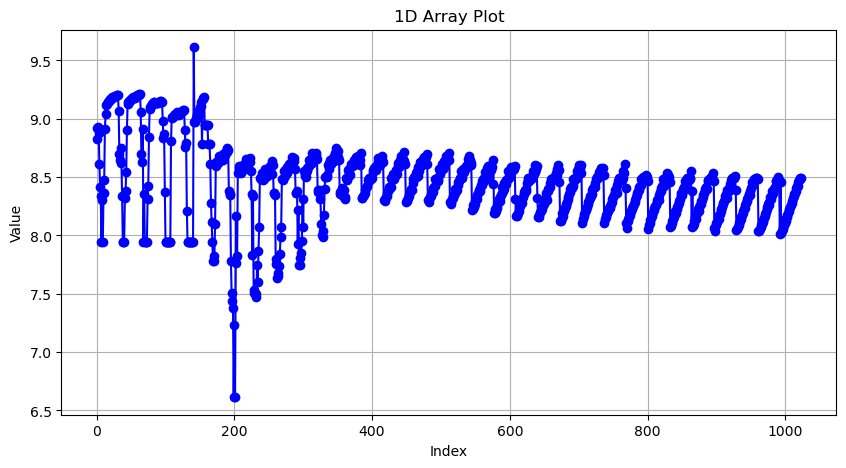

,Values
0,8.827698
1,8.920532
2,8.925049
3,8.881348
4,8.612762


In [6]:
print(type(z_pos_arr_cleaned_v))
print(z_pos_arr_cleaned_v)
print(np.array(z_pos_arr_cleaned_v).shape)
plt.figure(figsize=(10, 5))
plt.plot(z_pos_arr_cleaned_v, marker='o', linestyle='-', color='b')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('1D Array Plot')
plt.grid(True)
plt.show()

# Create DataFrame from the cleaned array
z_pos_df = pd.DataFrame(z_pos_arr_cleaned_v, columns=['Values'])

# Add NaN values to the end of the DataFrame
num_nan_to_add = 0 # Set this to how many NaN values you want to add to the end
for i in range(num_nan_to_add):
    z_pos_df = pd.concat([z_pos_df, pd.DataFrame([np.nan], columns=['Values'])], ignore_index=True)

z_pos_df.head()

In [7]:
# Check the shape and content of the DataFrame (not the original array)
print(f"Original array shape: {z_pos_arr_cleaned_v.shape}")
print(f"DataFrame shape: {z_pos_df.shape}")
print(f"DataFrame length: {len(z_pos_df)}")
print(f"Number of NaN values: {z_pos_df.isna().sum().sum()}")

# To see the NaN values, use tail() instead of head()
print("\nLast few rows:")
print(z_pos_df.tail())

# If you want to update your array to include the NaN values:
z_pos_arr_with_nan = z_pos_df['Values'].values
print(f"Updated array shape: {z_pos_arr_with_nan.shape}")

Original array shape: (1024,)
DataFrame shape: (1024, 1)
DataFrame length: 1024
Number of NaN values: 0

Last few rows:
        Values
1019  8.460541
1020  8.478180
1021  8.483093
1022  8.493683
1023  8.493591
Updated array shape: (1024,)


In [8]:
# if array is bigger than square length 
# get the square root of the shape
sqrt_len = int(np.sqrt(len(z_pos_arr_with_nan)))
print(f"Square root of the length: {sqrt_len}")
new_shape = sqrt_len**2
extra = len(z_pos_arr_with_nan) - new_shape
print(f'extra: {extra}')

# remove 4 values from end of z_pos_df
if extra!= 0:
    z_pos_df = z_pos_df.iloc[:-extra]

Square root of the length: 32
extra: 0


In [9]:
# if 

In [10]:
# reshape 1d array into 2d array
z_pos_2d = np.reshape(z_pos_df, (params['map_x_pix'], params['map_y_pix'])) 
# Mirror flip the 2D array along the vertical axis
z_pos_2d_flipped_v = np.flip(z_pos_2d, axis=1)
z_pos_2d_flipped_um = z_pos_2d_flipped_v.copy() * params['z_sens_um']

# create dataframe
z_pos_2d_flipped_um_df = pd.DataFrame(z_pos_2d_flipped_um)

z_pos_2d_flipped_um_df.head()
# print (z_pos_2d_flipped_um)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,55.222044,55.233582,55.218198,55.175352,55.174806,55.181946,55.140012,55.120788,55.125552,55.069884,...,47.677734,49.808532,47.677734,50.004636,50.510190,51.676572,53.288088,53.550294,53.523192,52.966188
1,55.281372,55.251162,55.238892,55.227540,55.198428,55.159056,55.178832,55.142580,55.088748,55.118592,...,49.899354,47.677734,47.677920,47.677734,50.025876,51.717222,52.519224,51.900510,52.209960,54.394590
2,54.847230,54.909852,54.866640,54.910584,54.841188,54.842652,54.823428,54.827088,54.809694,54.805482,...,47.677734,47.677734,47.677734,47.677734,50.119260,47.677920,53.452332,51.756042,52.167300,54.370608
3,54.471498,54.465822,54.411990,54.373536,54.327942,54.355956,54.293886,54.317502,54.190062,54.317874,...,47.677734,47.677734,47.677920,47.677734,47.677734,47.677734,50.244876,53.196348,52.991274,53.868894
4,53.677734,53.677734,53.677920,55.111818,55.077210,55.017882,52.677798,54.859128,54.646728,54.585390,...,47.677734,47.677920,47.677734,47.677734,47.677734,47.677734,49.280274,52.751952,52.571226,53.437134


5.685 3.96


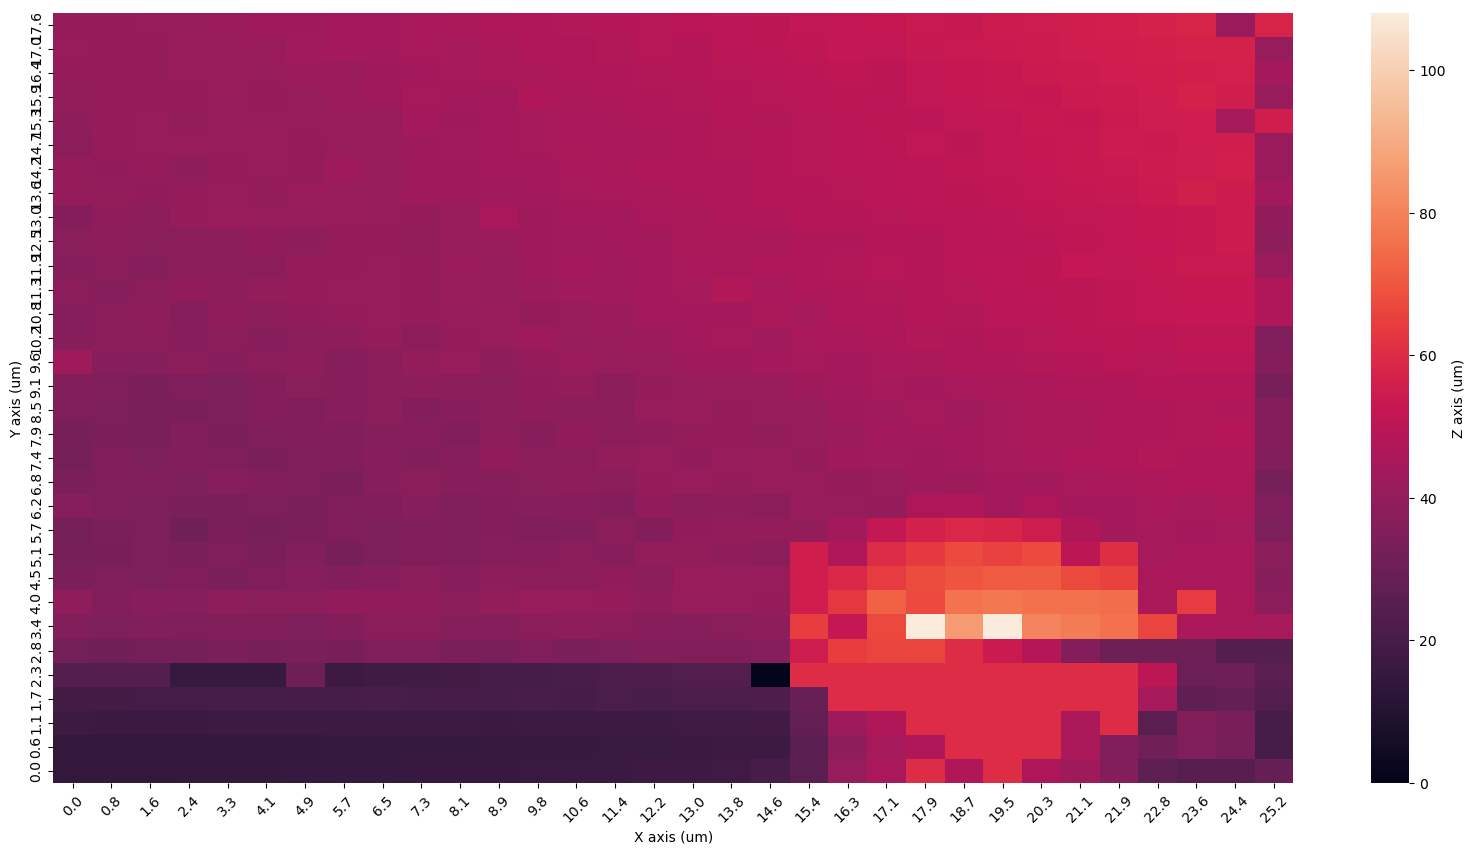

In [11]:

z_sens_um = 6 # um/V
map_test_um =z_pos_2d_flipped_um_df * z_sens_um

impulse_v = 1

map_dx_v = params['map_x_step']
map_dy_v = params['map_y_step']

# x_sens_nm = 5685   # um/V
# y_sens_nm = 3960   # um/V

# x_sens_um = x_sens_nm/1000
# y_sens_um = y_sens_nm/1000  

print (params['x_sens_um'], params['y_sens_um'])


map_test_um_zeroed = -map_test_um + map_test_um.max().max() #from the csv file
# print(map_test_um_zeroed)

# # plot map_test_um_zeroed and map_test_um on matplotlib
# fig, ax = plt.subplots(figsize=(15, 5))
# plt.plot(map_test_um_zeroed)
# plt.plot(map_test_um)
# plt.show()

x_axis = (map_test_um.columns * map_dx_v * params['x_sens_um']).round(1)
y_axis = (map_test_um.index * map_dy_v * params['y_sens_um']).round(1)

fig, ax = plt.subplots(figsize=(20, 10))  # Adjust the figsize as needed
# a = sns.heatmap(map_test_um_zeroed, xticklabels=x_axis, yticklabels=y_axis, ax=ax, vmin = 110, vmax=120)
# a = sns.heatmap(map_test_um_zeroed, xticklabels=x_axis, yticklabels=y_axis, ax=ax, vmin = 10, vmax=30)
a = sns.heatmap(map_test_um_zeroed, xticklabels=x_axis, yticklabels=y_axis, ax=ax)
a.invert_yaxis()

a.set_xlabel('X axis (um)')
a.set_ylabel('Y axis (um)')
# a.set_title(f'Heatmap from loaded csv file: {filename}')

colorbar = a.collections[0].colorbar
colorbar.set_label('Z axis (um)')
colorbar.ax.yaxis.label.set_rotation(90)  # Rotate the Z axis label
_ = plt.xticks(rotation=45)

# rotate y axis labels 45 degrees
_ = plt.yticks(rotation=90)




In [12]:
import pyfmreader.ps_nex.loadpsnexMaps as maps

df_map_test, map_x_pix, map_y_pix = maps.load_map_file_square_tdms(map_path)

# of files analyzed: 1024, closest shape: 32 x 32
 map metadata: map_x_step: 0.143, map_y_step: 0.143, map_x_init: 0.0, map_y_init: 0.0
 x_sens (um/V): 5.685, y_sens (um/V): 3.96, z_sens (um/V): 6.0, z_setpoint_trig (V): 8.493591


Are z_pos_2d and map_test_array the same? False


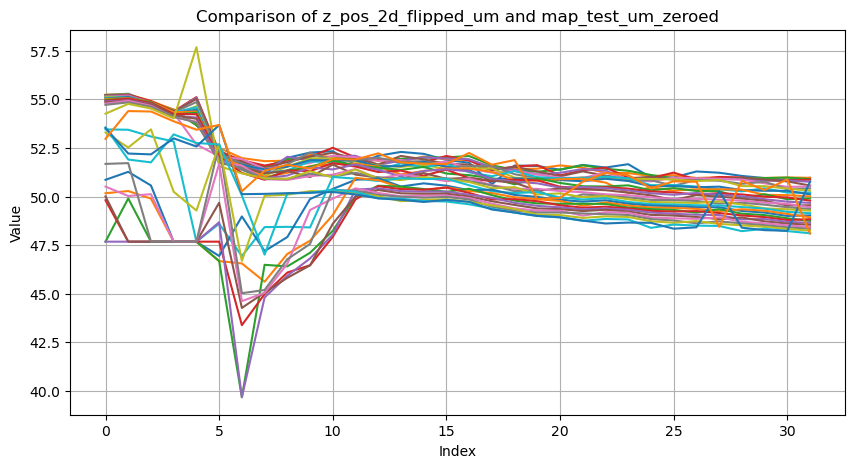

(32, 32) (32, 32)


In [13]:

# Convert map_test to a numpy array
map_test_arr_um = df_map_test.values


# Compare the map_test_array: contact position from the files loaded with respect to z_pos_2d : the image saved
arrays_equal = np.array_equal(z_pos_2d_flipped_um, map_test_um)
print("Are z_pos_2d and map_test_array the same?", arrays_equal)
# Plot the two arrays with respect to index
plt.figure(figsize=(10, 5))
plt.plot(z_pos_2d_flipped_um[::], label='z_pos_2d_flipped_um : force curves')
# plt.plot(map_test_arr_um.flatten(), label='map_test_arr_um: CSV')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Comparison of z_pos_2d_flipped_um and map_test_um_zeroed')
# plt.legend()
plt.grid(True)
plt.show()


print(np.shape(z_pos_2d_flipped_um), np.shape(map_test_um))

In [14]:
print(type(z_pos_2d_flipped_um))

<class 'numpy.ndarray'>


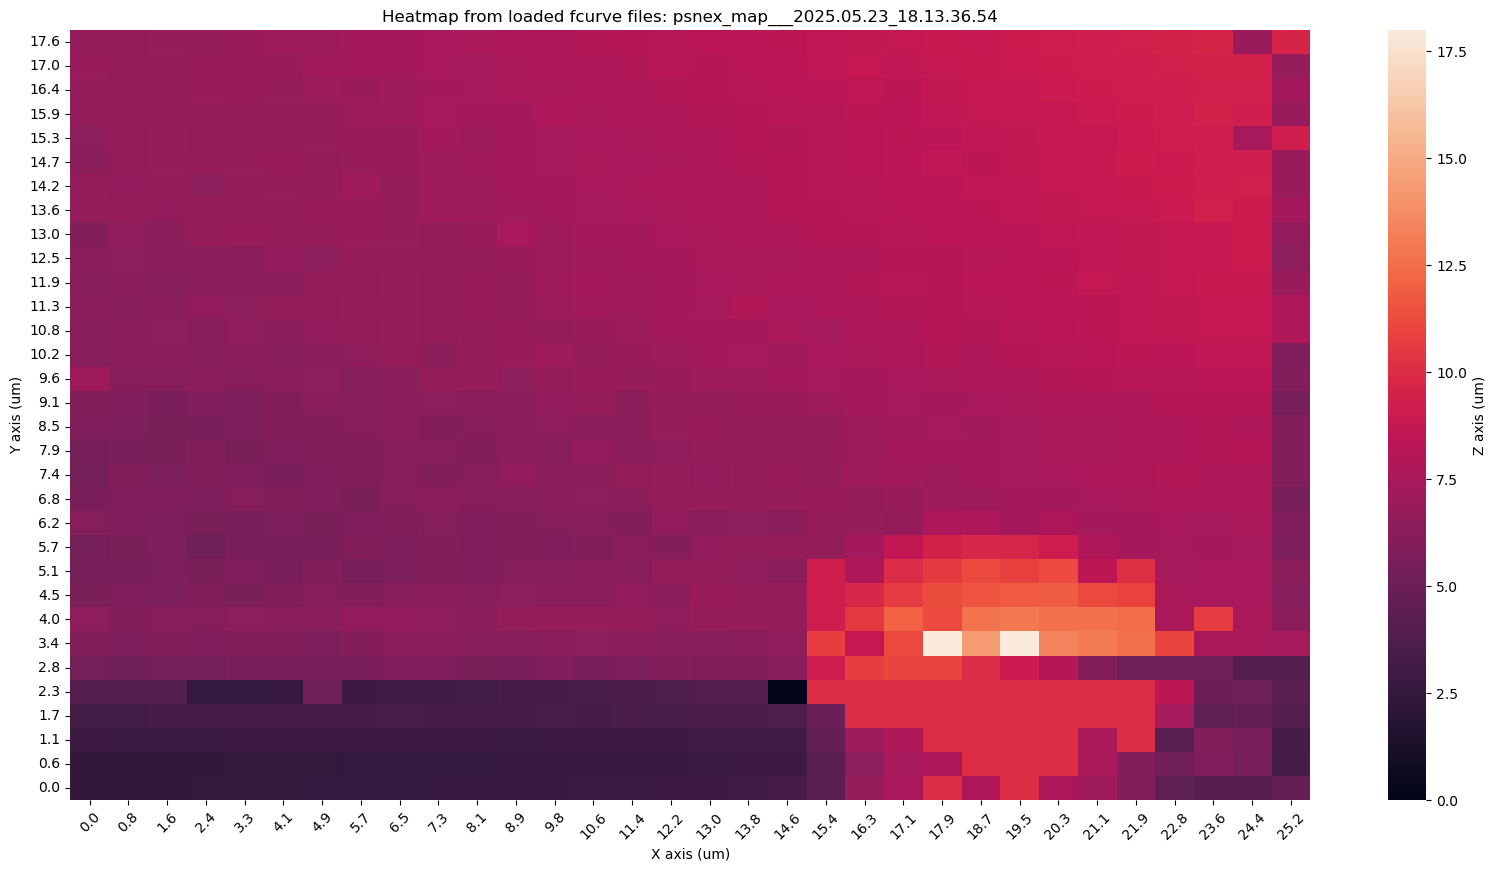

In [15]:
z_pos_2d_flipped_um_zeroed = -z_pos_2d_flipped_um + z_pos_2d_flipped_um.max().max() #from the csv file
fig, ax = plt.subplots(figsize=(20, 10))  # Adjust the figsize as needed
a = sns.heatmap(z_pos_2d_flipped_um_zeroed, xticklabels=x_axis, yticklabels=y_axis, ax=ax)
a.invert_yaxis()


a.set_xlabel('X axis (um)')
a.set_ylabel('Y axis (um)')

a.set_title(f'Heatmap from loaded fcurve files: {map_path[::].split("/") [-1]}')

colorbar = a.collections[0].colorbar
colorbar.set_label('Z axis (um)')
colorbar.ax.yaxis.label.set_rotation(90)  # Rotate the Z axis label
_ = plt.xticks(rotation=45)

In [16]:
import pyfmreader.ps_nex.loadpsnexMaps as maps
# maps.save_tiff_map()

maps.save_tiff_map(z_pos_2d_flipped_um_zeroed, map_dx_v * params['x_sens_um'], map_dy_v * params['y_sens_um'],
              os.path.join(os.path.dirname(map_path), f'map_zpos_contact___{os.path.basename(map_path)}.tiff'),
              title=f'map_zpos_contact___{os.path.basename(map_path)}',
              unit="um")    

Saved: /Users/evillz/Data/article/2025_23_05/map_zpos_contact___psnex_map___2025.05.23_18.13.36.54.tiff


In [17]:
# from pyfmreader.ps_nex.loadpsnexMaps import load_map_file_square_tdms, checkMapFileNULL
import pyfmreader.ps_nex.loadpsnexMaps as maps
map_path = '/Users/evillz/Data/article/2025_23_05/psnex_map___2025.05.23_18.13.36.54' #CTC44
map_path = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.20.12.77' # doesnt work
map_path = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45' # CTC 44 PFQNM. THIS ONE


In [18]:
df_map = maps.checkMapFileNULL(map_path)

processing file : /Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45
segment duration 3.82632, 
 numb of point cal (ticks, dec, sampling rate 23914, num pts stored per segment 23914
segment duration 4.239059999999999, 
 numb of point cal (ticks, dec, sampling rate 26494, num pts stored per segment 26492
df_point log made
segment duration 3.8515099999999998, 
 numb of point cal (ticks, dec, sampling rate 24071, num pts stored per segment 24071
segment duration 4.243512, 
 numb of point cal (ticks, dec, sampling rate 26521, num pts stored per segment 26520
df_point log made
segment duration 4.040252, 
 numb of point cal (ticks, dec, sampling rate 25251, num pts stored per segment 25251
segment duration 4.344186, 
 numb of point cal (ticks, dec, sampling rate 27151, num pts stored per segment 27149
df_point log made
segment duration 3.9409479999999997, 
 numb of point cal (ticks, dec, sampling rate 24630, num pts stored per segment 24630
segment duration 4.35457, 
 num

In [19]:
# Check if df_map exists and print its information
if 'df_map' in globals():
    print("Type of df_map:", type(df_map))
    print("Shape of df_map:", df_map.shape)
    
    # If df_map is a tuple (as returned by load_map_file_square_tdms)
    if isinstance(df_map, tuple):
        print("df_map is a tuple with", len(df_map), "elements")
        for i, item in enumerate(df_map):
            print(f"Element {i} type:", type(item))
            if hasattr(item, "shape"):
                print(f"Element {i} shape:", item.shape)
    
    # If it's a DataFrame, show more details
    elif isinstance(df_map, pd.DataFrame):
        print("First 5 rows of df_map:")
        print(df_map.head())
        print("\nColumns:", df_map.columns.tolist())
else:
    print("df_map is not defined yet")

Type of df_map: <class 'pandas.core.frame.DataFrame'>
Shape of df_map: (1010, 11)
First 5 rows of df_map:
                                            filepath  total_len  \
0  /Users/evillz/Data/CTC44/2025_12_03/psnex_map_...      50409   
1  /Users/evillz/Data/CTC44/2025_12_03/psnex_map_...      50595   
2  /Users/evillz/Data/CTC44/2025_12_03/psnex_map_...      52403   
3  /Users/evillz/Data/CTC44/2025_12_03/psnex_map_...      51848   
4  /Users/evillz/Data/CTC44/2025_12_03/psnex_map_...      52929   

   total_len_cal_tick  diff_cal  diff_store  total_len_stored_point  \
0               50408         1           3                   50406   
1               50592         3           4                   50591   
2               52402         1           3                   52400   
3               51846         2           4                   51844   
4               52927         2           3                   52926   

   store_nbpts_app  store_nbpts_ret  cal_nbpts_app  cal_nbpts_re

In [20]:
df_map = maps.load_map_file_square_tdms(map_path)    


# of files analyzed: 1010, closest shape: 31 x 31
 map metadata: map_x_step: 0.143, map_y_step: 0.200001, map_x_init: 0.0, map_y_init: 0.0
 x_sens (um/V): 5.685, y_sens (um/V): 3.96, z_sens (um/V): 6.0, z_setpoint_trig (V): 4.778046
Error reshaping z_height_um_sorted: cannot reshape array of size 1010 into shape (31,31)


In [21]:
import pyfmreader.ps_nex.loadpsnexMaps as maps
df_timestamps = maps.compute_time_difference(map_path)

Files processed: 1010, matches found: 1010

Time difference between first and last file HH:MM:SS:MS: 00:14:05:75


In [22]:
df_map_vs = maps.extract_map_parameters(map_path)
_,_,_ = maps.analyze_map_dimension(map)

# of files analyzed: 70, closest shape: 8 x 8
Error loading file /: 'NoneType' object has no attribute 'filemetadata'
'NoneType' object has no attribute 'filemetadata' encountered.


OSError: [Errno 30] Read-only file system: '/error_file'

In [ ]:
import pyfmreader.ps_nex.loadpsnexMaps as maps
map_path = '/Users/evillz/Data/article/2025_23_05/psnex_map___2025.05.23_18.13.36.54/psnex_map___2025.05.23_18.13.36.54_test.csv'

# i want to
df_map_csv = maps.load_map_df_file_csv(map_path)

In [ ]:
import pyfmreader.ps_nex.loadpsnexMaps as maps
map_path = '/Volumes/SSK Drive /new_maps/2024_06_12/2024_06_14/newCanti/map9_32x32_0.1x0.143'
df_map_test = maps.checkMapFileNULL(map_path)
print ('df_map_test_size:', df_map_test.shape)

In [ ]:
import pyfmreader.ps_nex.loadpsnexMaps as maps
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

test_path = '/Volumes/SSK Drive /new_maps/2024_06_12/2024_06_14/newCanti/map7_10x10'
# test_path = '/Volumes/SSK Drive /new_maps/2024_06_12/2024_06_14/newCanti/map4' #didnt work...
test_path = '/Volumes/SSK Drive /new_maps/2024_06_12/2024_06_14/newCanti/map9_32x32_0.1x0.143'

# test_path = '/Volumes/SSK Drive /new_maps/2024_06_12/2024_06_26/balls_of_Fury_Map_4'
# test_path = '/Volumes/home/Backup/DESKTOP-Q9VJ176_PSnex/D/PSnex/2024_06_26/balls_of_Fury_Map_4'
maps.checkMapFileNULL(test_path)
df_boom, map_x_pix, map_y_pix = maps.load_map_file_square_tdms(test_path)
print (len(df_boom))
df_timestamps = maps.compute_time_difference(test_path)

In [ ]:
import pyfmreader.ps_nex.loadpsnexMaps as maps
# Call the function
data_to_trim = maps.analyze_map_dimension(df_boom, map_x_pix, map_y_pix)
# print (df['z_height_um'])

In [ ]:
import os
# First, ensure df_boom is properly converted to a DataFrame if it's a dictionary
df_boom_df = pd.DataFrame(df_boom)

# Create a new dataframe to store the combined data
combined_df = pd.DataFrame()

# Add the timestamp information
combined_df['filename'] = df_timestamps['filepath']
combined_df['datetime'] = df_timestamps['datetime']

# match the filepath from df_timestamps to the filepath of df_boom_df
# Assuming df_boom_df has a 'filename' column that matches 'filepath' in df_timestamps
# If df_boom_df does not have a 'filename' column, you need to create one based on your data
# For this example, let's assume df_boom_df has an index that matches the filenames
# If not, you may need to adjust this part accordingly
# Extract just the filename part from the full filepath for merging
combined_df['filename_short'] = combined_df['filename'].apply(os.path.basename)

# Convert df_boom_df index to filenames for proper merging
df_boom_df['filename_short'] = df_boom_df['filepath'].apply(os.path.basename)

# Merge on the short filenames
combined_df = combined_df.merge(df_boom_df, on='filename_short', how='left')
# Now combined_df contains the timestamp and the corresponding data from df_boom_df
# Display the first few rows of the combined dataframe
# print(combined_df.head())



In [ ]:
# Extract the zeroed height data from df_boom
if data_to_trim == 0:
    map_test_um_zeroed = combined_df['z_height_um'][:]
else :
    map_test_um_zeroed = combined_df['z_height_um'][:-data_to_trim]
    print(f"Trimmed {data_to_trim} values from 'z_height_um'."  )
print (np.size(map_test_um_zeroed))

# # Remove the last value if needed
# map_test_um_zeroed = map_test_um_zeroed[:-1]
#
# map_x_pix = 15
# map_y_pix = 15

z_pos_2d = np.reshape(map_test_um_zeroed, (map_x_pix, map_y_pix)) 
# plot heatmap
fig, ax = plt.subplots(figsize=(20, 10))  # Adjust the figsize as needed
a = sns.heatmap(z_pos_2d, ax=ax)
a.invert_yaxis()

a.set_xlabel('X axis (um)')
a.set_ylabel('Y axis (um)')
# a.set_title(f'Heatmap: {filename}')

colorbar = a.collections[0].colorbar
colorbar.set_label('Z axis (um)')
colorbar.ax.yaxis.label.set_rotation(90)  # Rotate the Z axis label
_ = plt.xticks(rotation=45)
_ = plt.yticks(rotation=0)
